> **Chapter 12, Part 1** | Advanced lens. **Focus:** the minimum graph language the rest of the chapter needs, and a re-expression of Chapter 11.4 union-find as connected components on a thresholded match graph.

# Graphs as the Next Geometry

The Chapter 11.4 duplicate-cluster notebook uses union-find with a `parent` dictionary. That is graph theory in disguise. Once you name it as a graph, you inherit decades of language, primitives, and tools.

This notebook teaches the slice of NetworkX the rest of the chapter actually uses. No more.

## Outputs

- a working vocabulary: nodes, edges, paths, distance, neighborhoods, components, degree
- the 11.4 records and scores rebuilt as a NetworkX graph
- a side-by-side check that connected components match 11.4 union-find at the same threshold
- a degree-distribution view of the Karate club, which we revisit in 12.3 and 12.4

## Supporting reading

- Hagberg, A., Schult, D., and Swart, P. (2008). Exploring network structure, dynamics, and function using NetworkX.
- NetworkX reference: https://networkx.org/documentation/stable/

## Failure note

If you cannot run a single connected-components call on the 11.4 data and produce the same clusters the union-find code produced, the rest of the chapter will not stand up.

## How I would debug this

Build the smallest possible graph by hand (four records, three edges), run components, and verify the answer matches your mental model before scaling up.


In [1]:
import networkx as nx

g = nx.Graph()
g.add_nodes_from(["R1", "R2", "R3", "R4"])
g.add_edge("R1", "R2", weight=0.94)
g.add_edge("R2", "R3", weight=0.85)
g.add_edge("R3", "R4", weight=0.18)

print("nodes", list(g.nodes()))
print("edges", [(u, v, d.get("weight")) for u, v, d in g.edges(data=True)])
print("degree of R2", g.degree["R2"])
print("neighbors of R2", list(g.neighbors("R2")))
print("shortest path R1 to R4", nx.shortest_path(g, "R1", "R4"))
print("distance R1 to R4", nx.shortest_path_length(g, "R1", "R4"))


nodes ['R1', 'R2', 'R3', 'R4']
edges [('R1', 'R2', 0.94), ('R2', 'R3', 0.85), ('R3', 'R4', 0.18)]
degree of R2 2
neighbors of R2 ['R1', 'R3']
shortest path R1 to R4 ['R1', 'R2', 'R3', 'R4']
distance R1 to R4 3


In [2]:
import pandas as pd

records = pd.DataFrame(
    [
        {"record_id": "R1", "source": "crm", "name": "Acme Health", "city": "Chicago"},
        {"record_id": "R2", "source": "erp", "name": "ACME Health Inc", "city": "Chicago"},
        {"record_id": "R3", "source": "support", "name": "Acme Health", "city": "Skokie"},
        {"record_id": "R4", "source": "crm", "name": "Northwind Labs", "city": "Boston"},
        {"record_id": "R5", "source": "erp", "name": "Northwind Laboratories", "city": "Boston"},
        {"record_id": "R6", "source": "partner", "name": "North Wind Labs", "city": "Cambridge"},
        {"record_id": "R7", "source": "crm", "name": "Riverstone Foods", "city": "Austin"},
        {"record_id": "R8", "source": "support", "name": "River Stone Food Group", "city": "Austin"},
    ]
)

scores = pd.DataFrame(
    [
        ("R1", "R2", 0.94),
        ("R1", "R3", 0.89),
        ("R2", "R3", 0.85),
        ("R4", "R5", 0.96),
        ("R4", "R6", 0.84),
        ("R5", "R6", 0.82),
        ("R7", "R8", 0.87),
        ("R2", "R6", 0.32),
        ("R3", "R4", 0.18),
    ],
    columns=["left", "right", "score"],
)


def match_graph(score_frame: pd.DataFrame, threshold: float, ids: list[str]) -> nx.Graph:
    g = nx.Graph()
    g.add_nodes_from(ids)
    for row in score_frame.itertuples(index=False):
        if row.score >= threshold:
            g.add_edge(row.left, row.right, weight=row.score)
    return g


graph_at_086 = match_graph(scores, threshold=0.86, ids=records["record_id"].tolist())
print("nodes", graph_at_086.number_of_nodes(), "edges", graph_at_086.number_of_edges())

components = list(nx.connected_components(graph_at_086))
for i, comp in enumerate(components, start=1):
    print(f"C{i}", sorted(comp))


nodes 8 edges 4
C1 ['R1', 'R2', 'R3']
C2 ['R4', 'R5']
C3 ['R6']
C4 ['R7', 'R8']


In [3]:
def union_find_clusters(score_frame: pd.DataFrame, threshold: float, ids: list[str]) -> list[set[str]]:
    parent = {rid: rid for rid in ids}

    def find(x: str) -> str:
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a: str, b: str) -> None:
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for row in score_frame.itertuples(index=False):
        if row.score >= threshold:
            union(row.left, row.right)

    clusters: dict[str, set[str]] = {}
    for rid in ids:
        clusters.setdefault(find(rid), set()).add(rid)
    return list(clusters.values())


uf_clusters = union_find_clusters(scores, threshold=0.86, ids=records["record_id"].tolist())
nx_clusters = [set(c) for c in nx.connected_components(graph_at_086)]

uf_sorted = sorted([sorted(c) for c in uf_clusters])
nx_sorted = sorted([sorted(c) for c in nx_clusters])
assert uf_sorted == nx_sorted, "NetworkX components and union-find disagree"
print("agreement at threshold 0.86:", uf_sorted)


agreement at threshold 0.86: [['R1', 'R2', 'R3'], ['R4', 'R5'], ['R6'], ['R7', 'R8']]


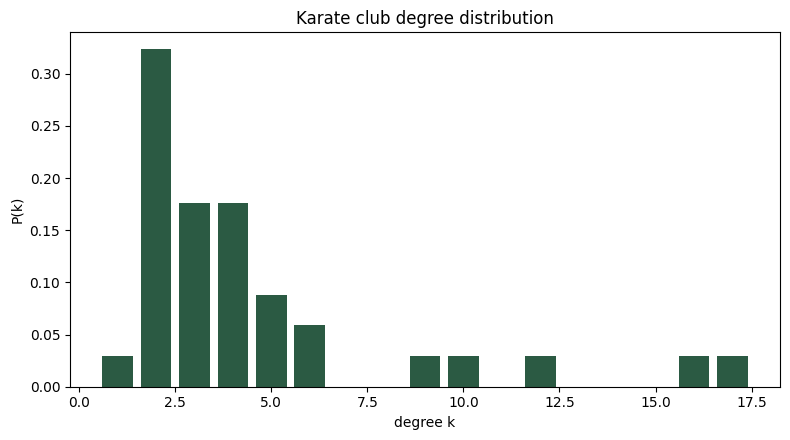

In [4]:
import matplotlib.pyplot as plt
from collections import Counter

karate = nx.karate_club_graph()
degree_seq = [deg for _, deg in karate.degree()]
counts = Counter(degree_seq)
ks = sorted(counts.keys())
ps = [counts[k] / len(degree_seq) for k in ks]

plt.figure(figsize=(8, 4.5))
plt.bar(ks, ps, color="#2b5a43")
plt.xlabel("degree k")
plt.ylabel("P(k)")
plt.title("Karate club degree distribution")
plt.tight_layout()
plt.show()


## Reading the result

The NetworkX `connected_components` answer matched the 11.4 union-find answer at threshold 0.86. That equivalence is the point. Once you have the graph, you also have access to descriptors union-find never produced: degree distributions, betweenness centralities, communities, and (in 12.3) box-coverings.

The Karate degree distribution is short-tailed and irregular. It is not a power law. We use it later because it is small enough to box-cover in seconds, and real enough to teach the right lessons about finite-size effects.

## Where this can go wrong

- `match_graph` ignores edge weights when running connected components. Two records with weight 0.86 and weight 0.99 contribute identically to component membership. We fix that gap in 12.6, where local box dimension and skeleton ratio bring weight back into the picture.
- `connected_components` does not run on a `DiGraph`. Lineage in 12.5 needs `weakly_connected_components` or `strongly_connected_components` depending on the question.

## Exercise

1. add an edge `("R6", "R7")` with weight 0.78. At which threshold does it change the cluster picture?
2. compute the degree distribution of the threshold-0.84 match graph. Compare to the 0.86 case.
3. write down one pair of records you would refuse to merge no matter the score, and explain which graph descriptor would make that refusal visible.
